In [2]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from arch import arch_model
from statsmodels.stats.diagnostic import het_arch
from statsmodels.graphics.tsaplots import plot_acf
from scipy import stats

from glencore_multi_agent.data import load_glencore

# Load data — uses cache from Stage 0
df = load_glencore()
returns = df["log_return"].dropna()

# arch library expects returns in percent scale (multiplied by 100)
# This improves numerical stability during optimisation
returns_pct = returns * 100

print(f"Series: {len(returns)} daily log returns")
print(f"Date range: {returns.index[0].date()} → {returns.index[-1].date()}")
print(f"Mean:     {returns.mean()*100:.4f}% per day")
print(f"Std:      {returns.std()*100:.4f}% per day")
print(f"Skew:     {returns.skew():.4f}")
print(f"Kurtosis: {returns.kurtosis():.4f}  (normal = 0)")

  Cached to data/raw/glen_raw.csv

Glencore loaded: 3807 rows, 2011-05-20 → 2026-06-19
Series: 3807 daily log returns
Date range: 2011-05-20 → 2026-06-19
Mean:     0.0015% per day
Std:      2.5811% per day
Skew:     -0.7222
Kurtosis: 14.0307  (normal = 0)


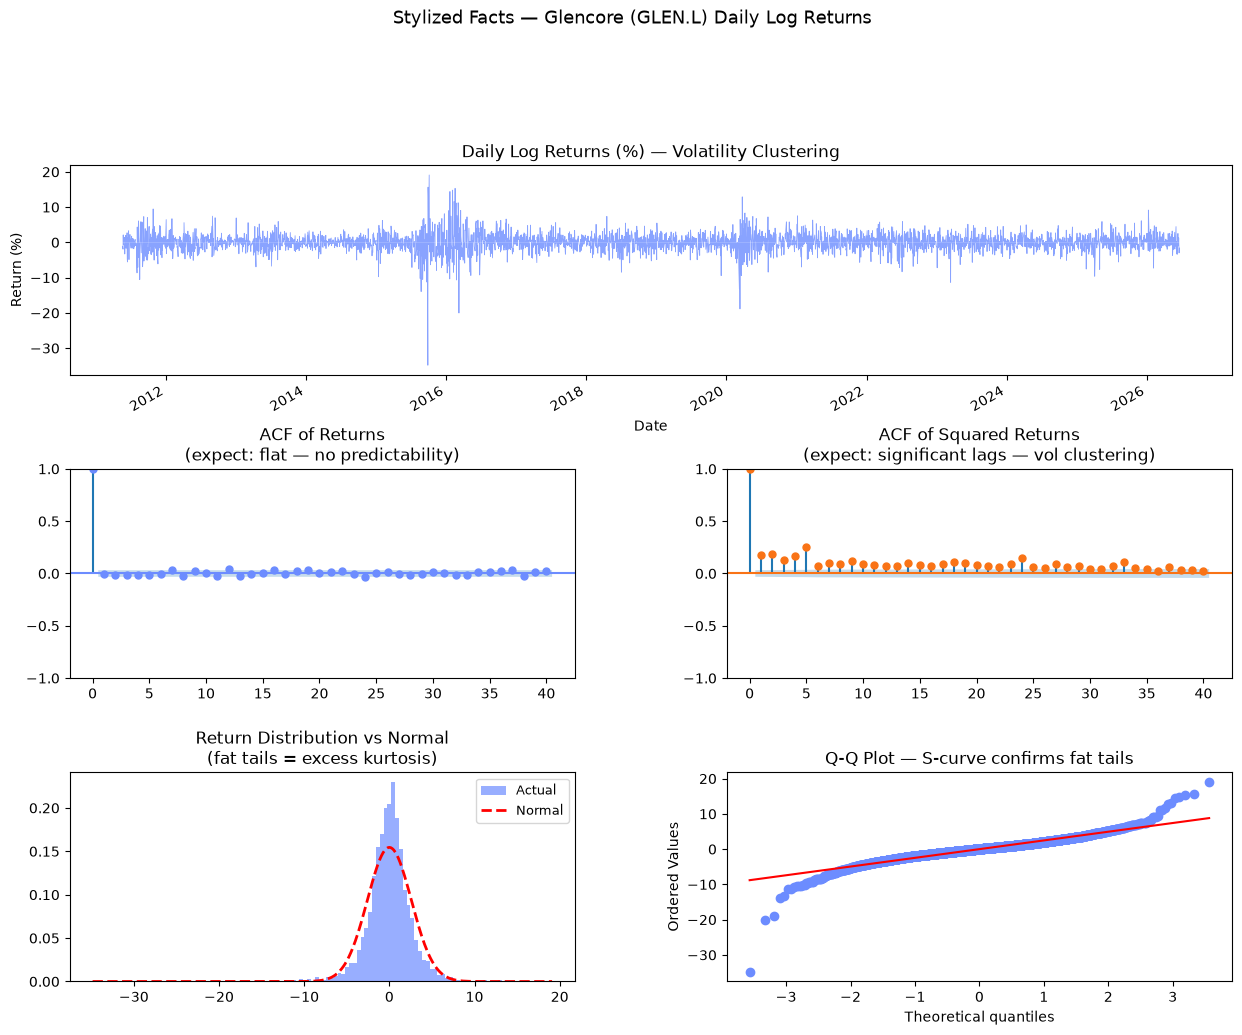


Kurtosis (excess): 14.031  (normal = 0)
Jarque-Bera: stat=31468.5, p=0.00e+00  (p≪0.05 → not normal)


In [3]:
fig = plt.figure(figsize=(15, 12))
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.3)

# ── 1. Returns time series — look for clustering ────────────────────────
ax1 = fig.add_subplot(gs[0, :])
returns_pct.plot(ax=ax1, color="#6c8cff", lw=0.6, alpha=0.8)
ax1.axhline(0, color="white", lw=0.4, alpha=0.3)
ax1.set_title("Daily Log Returns (%) — Volatility Clustering", fontsize=12)
ax1.set_ylabel("Return (%)")

# ── 2. ACF of raw returns — should show NO significant lags ─────────────
ax2 = fig.add_subplot(gs[1, 0])
plot_acf(returns_pct, lags=40, ax=ax2, color="#6c8cff", alpha=0.05)
ax2.set_title("ACF of Returns\n(expect: flat — no predictability)")

# ── 3. ACF of SQUARED returns — should show significant lags ────────────
ax3 = fig.add_subplot(gs[1, 1])
plot_acf(returns_pct**2, lags=40, ax=ax3, color="#f97316", alpha=0.05)
ax3.set_title("ACF of Squared Returns\n(expect: significant lags — vol clustering)")

# ── 4. Return distribution vs normal ────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 0])
ax4.hist(returns_pct, bins=120, density=True, color="#6c8cff", alpha=0.7, label="Actual")
x = np.linspace(returns_pct.min(), returns_pct.max(), 300)
ax4.plot(x, stats.norm.pdf(x, returns_pct.mean(), returns_pct.std()),
        "r--", lw=2, label="Normal")
ax4.set_title("Return Distribution vs Normal\n(fat tails = excess kurtosis)")
ax4.legend(fontsize=9)

# ── 5. Q-Q plot ──────────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 1])
stats.probplot(returns_pct, dist="norm", plot=ax5)
ax5.set_title("Q-Q Plot — S-curve confirms fat tails")
ax5.get_lines()[0].set_color("#6c8cff")

plt.suptitle("Stylized Facts — Glencore (GLEN.L) Daily Log Returns",
             fontsize=13, y=1.01)
plt.savefig("../reports/figures/stage2_stylized_facts.png",
            dpi=150, bbox_inches="tight")
plt.show()

print(f"\nKurtosis (excess): {returns_pct.kurtosis():.3f}  (normal = 0)")
jb_stat, jb_p = stats.jarque_bera(returns_pct)
print(f"Jarque-Bera: stat={jb_stat:.1f}, p={jb_p:.2e}  (p≪0.05 → not normal)")

In [4]:
from statsmodels.stats.diagnostic import het_arch
from statsmodels.stats.stattools import durbin_watson

# ── Engle's ARCH-LM test ────────────────────────────────────────────────
# H0: no ARCH effects (constant variance)
# p < 0.05 → reject H0 → ARCH effects present → GARCH is justified
lm_stat, lm_p, f_stat, f_p = het_arch(returns_pct, nlags=10)

print("── Engle's ARCH-LM Test ────────────────────────────────────")
print(f"Null hypothesis: no ARCH effects (constant variance)")
print(f"LM statistic:    {lm_stat:.4f}")
print(f"LM p-value:      {lm_p:.2e}")
print(f"F statistic:     {f_stat:.4f}")
print(f"F p-value:       {f_p:.2e}")

if lm_p < 0.05:
    print("\n✓ ARCH effects confirmed — GARCH modelling is justified")
else:
    print("\n✗ No ARCH effects detected — reconsider modelling approach")

# ── Ljung-Box on squared returns ────────────────────────────────────────
from statsmodels.stats.diagnostic import acorr_ljungbox
lb_result = acorr_ljungbox(returns_pct**2, lags=[5, 10, 20], return_df=True)
print("\n── Ljung-Box on Squared Returns ────────────────────────────")
print("Null: no autocorrelation in squared returns up to lag k")
print(lb_result.to_string())

── Engle's ARCH-LM Test ────────────────────────────────────
Null hypothesis: no ARCH effects (constant variance)
LM statistic:    424.2370
LM p-value:      6.49e-85
F statistic:     47.6215
F p-value:       3.36e-90

✓ ARCH effects confirmed — GARCH modelling is justified

── Ljung-Box on Squared Returns ────────────────────────────
Null: no autocorrelation in squared returns up to lag k
        lb_stat      lb_pvalue
5    656.039431  1.566917e-139
10   827.899010  2.069184e-171
20  1117.753233  2.858167e-224


                     Constant Mean - GARCH Model Results                      
Dep. Variable:             log_return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -8448.81
Distribution:                  Normal   AIC:                           16905.6
Method:            Maximum Likelihood   BIC:                           16930.6
                                        No. Observations:                 3807
Date:                Tue, Jun 23 2026   Df Residuals:                     3806
Time:                        02:39:16   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu             0.0322  3.248e-02      0.992      0.321 

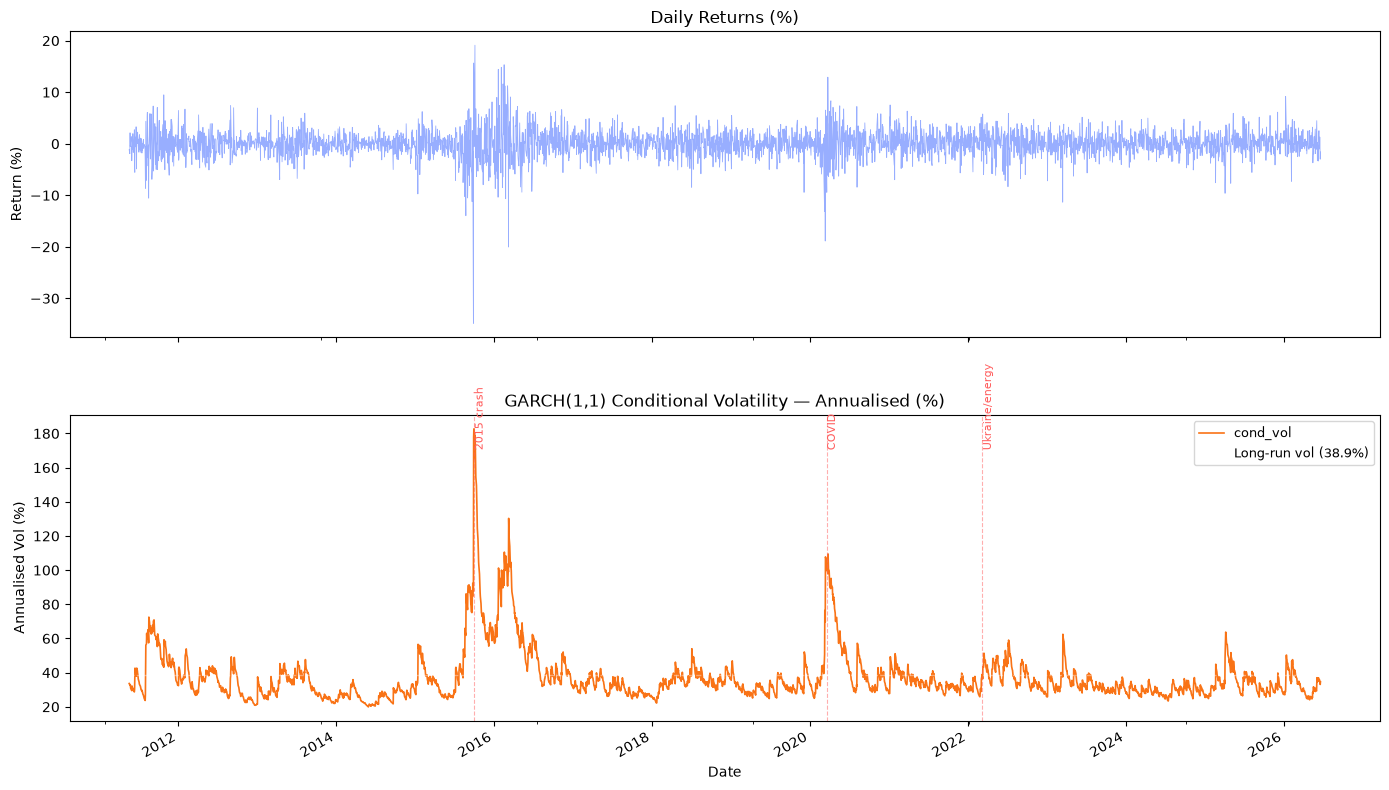

In [5]:
# ── Fit GARCH(1,1) with normal innovations ───────────────────────────────
garch11 = arch_model(
    returns_pct,
    vol="Garch",
    p=1, q=1,
    dist="normal",
    mean="constant",
)
res11 = garch11.fit(disp="off")
print(res11.summary())

# ── Extract and interpret key parameters ────────────────────────────────
p = res11.params
alpha = p["alpha[1]"]
beta  = p["beta[1]"]
omega = p["omega"]
persistence = alpha + beta
lr_var = omega / (1 - persistence)
lr_vol_ann = np.sqrt(lr_var * 252)

print("\n── Parameter Interpretation ────────────────────────────────")
print(f"omega:       {omega:.6f}  (baseline variance)")
print(f"alpha:       {alpha:.4f}    (shock impact — news response)")
print(f"beta:        {beta:.4f}    (persistence — memory)")
print(f"alpha+beta:  {persistence:.4f}    (total persistence)")
print(f"Long-run annualised vol: {lr_vol_ann:.2f}%")

# Half-life of a volatility shock (in days)
# How long until a shock decays to half its original impact
half_life = np.log(0.5) / np.log(persistence)
print(f"Shock half-life:         {half_life:.1f} trading days")

# Current conditional vol (annualised)
cond_vol_today = float(res11.conditional_volatility.iloc[-1]) * np.sqrt(252)
print(f"Current conditional vol: {cond_vol_today:.2f}% (annualised)")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Returns
returns_pct.plot(ax=ax1, color="#6c8cff", lw=0.6, alpha=0.7)
ax1.set_title("Daily Returns (%)")
ax1.set_ylabel("Return (%)")

# GARCH conditional volatility (annualised)
cond_vol = res11.conditional_volatility * np.sqrt(252)
cond_vol.plot(ax=ax2, color="#f97316", lw=1.2)
ax2.axhline(lr_vol_ann, color="white", lw=1, ls="--", alpha=0.4,
           label=f"Long-run vol ({lr_vol_ann:.1f}%)")
ax2.set_title("GARCH(1,1) Conditional Volatility — Annualised (%)")
ax2.set_ylabel("Annualised Vol (%)")
ax2.legend(fontsize=9)

# Annotate the regime breaks
for date, label in [
    ("2015-09-29", "2015 crash"),
    ("2020-03-18", "COVID"),
    ("2022-03-07", "Ukraine/energy"),
]:
    ax2.axvline(pd.Timestamp(date), color="#ff5f5f", lw=0.8,
               ls="--", alpha=0.5)
    ax2.text(pd.Timestamp(date), ax2.get_ylim()[1]*0.9,
             label, fontsize=8, color="#ff5f5f", rotation=90)

plt.tight_layout()
plt.savefig("../reports/figures/stage2_garch_conditional_vol.png",
            dpi=150, bbox_inches="tight")
plt.show()

── Model Comparison ────────────────────────────────────────
Model                       AIC        BIC        Log-L
-------------------------------------------------------
GARCH(1,1)             16905.61   16930.59     -8448.81
GJR-GARCH(1,1)         16877.85   16909.08     -8433.93
EGARCH(1,1)            16922.54   16947.52     -8457.27

GJR gamma:   0.0619  (p=0.0076)
✓ Leverage effect confirmed: negative shocks increase vol more than positive

EGARCH parameters available:
['mu', 'omega', 'alpha[1]', 'beta[1]']


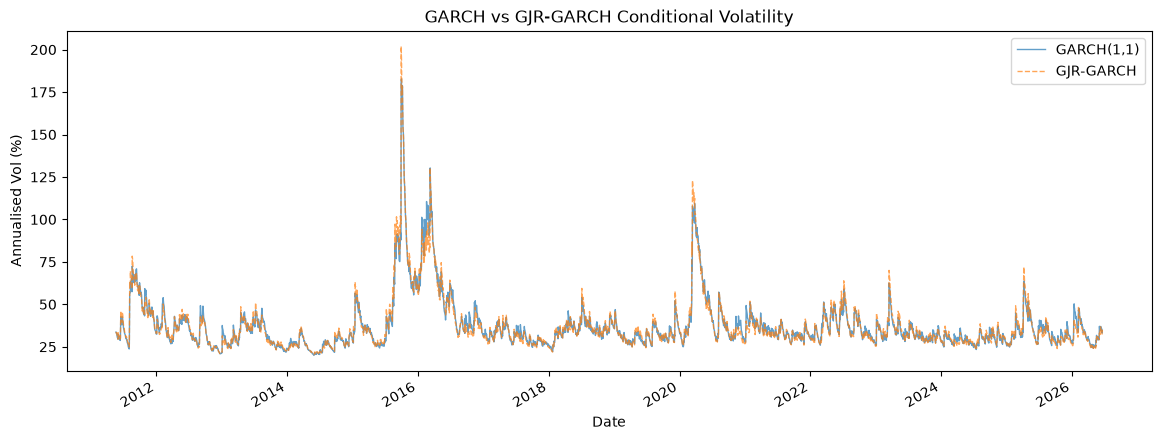

In [8]:
# ── GJR-GARCH(1,1) ───────────────────────────────────────────────────────
# vol="Garch" + o=1 adds the asymmetric term (gamma)
gjr = arch_model(returns_pct, vol="Garch", p=1, o=1, q=1, dist="normal")
res_gjr = gjr.fit(disp="off")

# ── EGARCH(1,1) ──────────────────────────────────────────────────────────
egarch = arch_model(returns_pct, vol="EGARCH", p=1, q=1, dist="normal")
res_egarch = egarch.fit(disp="off")

# ── Model comparison ─────────────────────────────────────────────────────
# AIC and BIC: lower is better; BIC penalises extra parameters more
print("── Model Comparison ────────────────────────────────────────")
print(f"{'Model':<20} {'AIC':>10} {'BIC':>10} {'Log-L':>12}")
print("-" * 55)
for name, res in [
    ("GARCH(1,1)", res11),
    ("GJR-GARCH(1,1)", res_gjr),
    ("EGARCH(1,1)", res_egarch),
]:
    print(f"{name:<20} {res.aic:>10.2f} {res.bic:>10.2f} {res.loglikelihood:>12.2f}")

# ── GJR gamma parameter — the leverage test ──────────────────────────────
gamma   = res_gjr.params.get("gamma[1]", None)
gamma_p = res_gjr.pvalues.get("gamma[1]", None)

if gamma is not None and gamma_p is not None:
    print(f"\nGJR gamma:   {gamma:.4f}  (p={gamma_p:.4f})")
    if gamma > 0 and gamma_p < 0.05:
        print("✓ Leverage effect confirmed: negative shocks increase vol more than positive")
    else:
        print("✗ Leverage effect not statistically significant at 5%")

# ── EGARCH gamma — print available params to find the right name ─────────
print("\nEGARCH parameters available:")
print(res_egarch.params.index.tolist())

# ── Plot conditional vol comparison ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
(res11.conditional_volatility * np.sqrt(252)).plot(
    ax=ax, label="GARCH(1,1)", lw=1, alpha=0.7)
(res_gjr.conditional_volatility * np.sqrt(252)).plot(
    ax=ax, label="GJR-GARCH", lw=1, alpha=0.7, ls="--")
ax.set_title("GARCH vs GJR-GARCH Conditional Volatility")
ax.set_ylabel("Annualised Vol (%)")
ax.legend()
plt.savefig("../reports/figures/stage2_model_comparison.png",
            dpi=150, bbox_inches="tight")
plt.show()

In [9]:
# Use the best model from Cell 5 — replace res11 with res_gjr if it won
best_model = res_gjr  # change to res11 if GARCH(1,1) had lower AIC
best_name  = "GJR-GARCH(1,1)"

# ── 5-day ahead volatility forecast ─────────────────────────────────────
forecast = best_model.forecast(horizon=5, reindex=False)
fcast_var = forecast.variance.iloc[-1]  # variance in pct² scale
fcast_vol_daily = np.sqrt(fcast_var)
fcast_vol_ann   = fcast_vol_daily * np.sqrt(252)

print("── 5-Day Forward Volatility Forecast ───────────────────────")
print(f"Model: {best_name}")
print(f"{'Day':<6} {'Daily Vol':>12} {'Ann. Vol':>12}")
print("-" * 32)
for i, (dv, av) in enumerate(zip(fcast_vol_daily, fcast_vol_ann), 1):
    print(f"t+{i:<4} {dv:>11.3f}% {av:>11.2f}%")

# ── Value at Risk ────────────────────────────────────────────────────────
# VaR = mean + z_quantile * sigma (in percent, then convert back)
current_sigma = float(best_model.conditional_volatility.iloc[-1])
mu = float(best_model.params.get("mu", 0))

print("\n── Value at Risk (1-day) ────────────────────────────────────")
print(f"Current conditional vol: {current_sigma:.3f}%/day ({current_sigma*np.sqrt(252):.2f}% ann.)")
print()

for conf, label in [(0.95, "95%"), (0.99, "99%")]:
    z = stats.norm.ppf(1 - conf)  # negative (left tail)
    var_pct = mu + z * current_sigma
    print(f"  {label} 1-day VaR: {var_pct:.3f}%")
    print(f"  → On 1 in {int(1/(1-conf))} trading days, expect loss > {abs(var_pct):.2f}%")
    print()

# ── Historical VaR violations ────────────────────────────────────────────
# Check what % of actual returns breached the VaR threshold — should be ~5%
var_95_series = (mu + stats.norm.ppf(0.05) * best_model.conditional_volatility)
violations = (returns_pct < var_95_series).sum()
violation_rate = violations / len(returns_pct) * 100
print(f"95% VaR violation rate: {violation_rate:.2f}%  (target: 5.00%)")
print(f"  {violations} days out of {len(returns_pct)} breached the 95% VaR threshold")

── 5-Day Forward Volatility Forecast ───────────────────────
Model: GJR-GARCH(1,1)
Day       Daily Vol     Ann. Vol
--------------------------------
t+1          2.186%       34.70%
t+2          2.190%       34.77%
t+3          2.195%       34.85%
t+4          2.200%       34.92%
t+5          2.204%       34.99%

── Value at Risk (1-day) ────────────────────────────────────
Current conditional vol: 2.202%/day (34.95% ann.)

  95% 1-day VaR: -3.621%
  → On 1 in 19 trading days, expect loss > 3.62%

  99% 1-day VaR: -5.122%
  → On 1 in 99 trading days, expect loss > 5.12%

95% VaR violation rate: 5.02%  (target: 5.00%)
  191 days out of 3807 breached the 95% VaR threshold


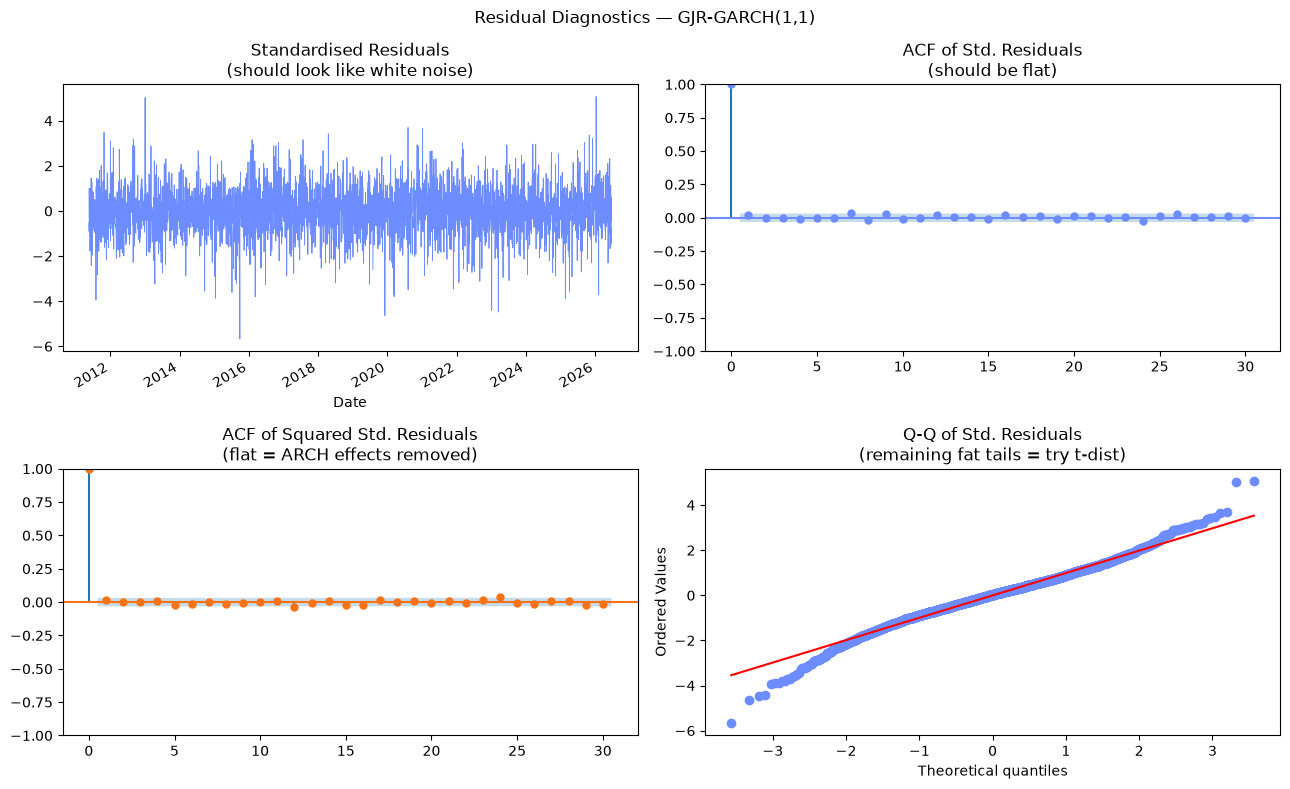

ARCH-LM on std. residuals: p=0.8150
✓ No remaining ARCH effects — model is well specified


In [10]:
# Standardised residuals: actual return / conditional vol
std_resid = best_model.resid / best_model.conditional_volatility

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# 1. Standardised residuals over time — should look like white noise
std_resid.plot(ax=axes[0,0], color="#6c8cff", lw=0.6)
axes[0,0].set_title("Standardised Residuals\n(should look like white noise)")

# 2. ACF of standardised residuals — should be flat
plot_acf(std_resid, lags=30, ax=axes[0,1], color="#6c8cff", alpha=0.05)
axes[0,1].set_title("ACF of Std. Residuals\n(should be flat)")

# 3. ACF of SQUARED standardised residuals — should also be flat
# If still significant: ARCH effects remain — model is misspecified
plot_acf(std_resid**2, lags=30, ax=axes[1,0], color="#f97316", alpha=0.05)
axes[1,0].set_title("ACF of Squared Std. Residuals\n(flat = ARCH effects removed)")

# 4. Q-Q plot of standardised residuals
stats.probplot(std_resid, dist="norm", plot=axes[1,1])
axes[1,1].set_title("Q-Q of Std. Residuals\n(remaining fat tails = try t-dist)")
axes[1,1].get_lines()[0].set_color("#6c8cff")

plt.suptitle(f"Residual Diagnostics — {best_name}", fontsize=12)
plt.tight_layout()
plt.savefig("../reports/figures/stage2_residual_diagnostics.png",
            dpi=150, bbox_inches="tight")
plt.show()

# Formal test: ARCH-LM on standardised residuals
# Should NOT be significant if model captured the effects
lm2, lm2_p, _, _ = het_arch(std_resid, nlags=10)
print(f"ARCH-LM on std. residuals: p={lm2_p:.4f}")
if lm2_p > 0.05:
    print("✓ No remaining ARCH effects — model is well specified")
else:
    print("⚠ ARCH effects remain in residuals — consider higher order or t-distribution")

In [11]:
gjr_t = arch_model(returns_pct, vol="Garch", p=1, o=1, q=1, dist="t")
res_gjr_t = gjr_t.fit(disp="off")

nu = res_gjr_t.params["nu"]  # degrees of freedom
print(f"Student-t degrees of freedom: {nu:.2f}")
print(f"  (low value = heavy tails; normal approximation at ~30+)")
print(f"AIC improvement: {res_gjr_t.aic - res_gjr.aic:.2f}")

Student-t degrees of freedom: 6.01
  (low value = heavy tails; normal approximation at ~30+)
AIC improvement: -189.18
